In [3]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
import seaborn as sns
from matplotlib.patches import Patch

**Steps to prepare the time series data for line plots:**
>1. Grouping the panel data by time and summing over the countries to get total value of trade for unique and reproducible cultural goods and total merchandise trade for all years
>2. Merginf this grouped data with cleaned network metrics datasets on time, so that the new dataframe will have 24 rows one for each year, and 15 columns(4 types of global culstering coefficient from each dataset and the three columns with total value of unique, and reproducible cultural goods and total goods trade)

In [4]:
u = pd.read_csv("../data/cleaned/unique_edgelist.csv")
r = pd.read_csv("../data/cleaned/reproducible_edgelist.csv")
t = pd.read_csv("../data/cleaned/total_edgelist.csv")
u_net = pd.read_csv("../data/cleaned/network_metrics_u.csv")
r_net = pd.read_csv("../data/cleaned/network_metrics_r.csv")
t_net = pd.read_csv("../data/cleaned/network_metrics_t.csv")

In [5]:
year_column = [str(y) for y in range(1995, 2024)]
binary_u = u.copy()
binary_t = t.copy()
binary_r = r.copy()
binary_u[year_column] = (binary_u[year_column] > 0).astype(int)
binary_r[year_column] = (binary_r[year_column] > 0).astype(int)
binary_t[year_column] = (binary_t[year_column] > 0).astype(int)

In [6]:
def persistence_count(df, year_columns):  
    """ It assigns previous year and current year to variables, then counts total ties in previous year 'prev_total'.
    Then it counts persisted and newly formed ties as 'persisted', 'dissoluted', and 'formed'. Then it counts the survival rate, 
    formation rate and dissolution rate and stores all measures to the measures list"""
    measures = []   
    for i in range(1, len(year_columns)):        
        prev_year = year_columns[i - 1]
        curr_year = year_columns[i]       
        prev_total = (df[prev_year] == 1).sum()
        persisted = ((df[prev_year] == 1) & (df[curr_year] == 1)).sum()
        formed = ((df[prev_year] == 0) & (df[curr_year] == 1)).sum()
        dissolved = ((df[prev_year] == 1) & (df[curr_year] == 0)).sum()
        measures.append({
            "year": curr_year,
            "total_previous_ties": prev_total,
            "persisted_ties": persisted,
            "new_ties": formed,
            "dissolved_ties": dissolved,
            "survival_rate": persisted / prev_total if prev_total > 0 else 0,
            "formation_rate": formed / prev_total if prev_total > 0 else 0,
            "dissolution_rate": dissolved / prev_total if prev_total > 0 else 0
        })    
    return pd.DataFrame(measures)

In [7]:
u_count = persistence_count(binary_u, year_column)
r_count = persistence_count(binary_r, year_column)
t_count = persistence_count(binary_t, year_column)

In [8]:
rename_u = {"total_previous_ties": "total_previous_u_ties", "persisted_ties": "persisted_u","dissolved_ties": "dissolved_u", "new_ties":"new_u", "survival_rate":"survival_rate_u", "formation_rate":"formation_rate_u", "dissolution_rate": "dissolution_rate_u"}
u_count = u_count.rename(columns = rename_u)

In [9]:
rename_r = {"total_previous_ties": "total_previous_r_ties", "persisted_ties": "persisted_r","dissolved_ties": "dissolved_r", "new_ties":"new_r", "survival_rate":"survival_rate_r", "formation_rate":"formation_rate_r", "dissolution_rate": "dissolution_rate_r"}
r_count = r_count.rename(columns = rename_r)

In [10]:
rename_t = {"total_previous_ties": "total_previous_t_ties", "persisted_ties": "persisted_t","dissolved_ties": "dissolved_t", "new_ties":"new_t", "survival_rate":"survival_rate_t", "formation_rate":"formation_rate_t", "dissolution_rate": "dissolution_rate_t"}
t_count = t_count.rename(columns = rename_t)

In [11]:
persistence = u_count.merge(r_count, on = 'year', how = 'left').merge(t_count, on = 'year', how = 'left')

In [12]:
persistence.shape

(28, 22)

In [13]:
r_net.head()

,Unnamed: 0,country,alpha,out_deg,in_deg,clustering,year,n_nodes,n_edges,density,reciprocity,transitivity,avg_path_length
0,1,ABW,0.5,2.463224,4.793344,0.961951,1995,182,7406,0.224819,0.618688,0.542139,0.001568
1,2,AFG,0.5,3.010443,4.390450,0.991262,1995,182,7406,0.224819,0.618688,0.542139,0.001568
2,3,AGO,0.5,2.563945,6.905413,0.939073,1995,182,7406,0.224819,0.618688,0.542139,0.001568
3,4,ALB,0.5,4.312870,7.909544,0.926029,1995,182,7406,0.224819,0.618688,0.542139,0.001568
4,5,AND,0.5,5.142189,9.874345,0.986894,1995,182,7406,0.224819,0.618688,0.542139,0.001568


In [14]:
t_net.head()

,Unnamed: 0,country,alpha,out_deg,in_deg,clustering,year,n_nodes,n_edges,density,reciprocity,transitivity,avg_path_length
0,1,ABW,0.5,31.666126,30.750920,0.974663,1995,182,19347,0.587305,0.828862,0.792803,0.005048
1,2,AFG,0.5,18.066393,26.817452,0.972620,1995,182,19347,0.587305,0.828862,0.792803,0.005048
2,3,AGO,0.5,64.363706,47.946525,0.990649,1995,182,19347,0.587305,0.828862,0.792803,0.005048
3,4,ALB,0.5,24.078716,38.901531,0.976849,1995,182,19347,0.587305,0.828862,0.792803,0.005048
4,5,AND,0.5,13.561997,40.624632,0.998229,1995,182,19347,0.587305,0.828862,0.792803,0.005048


In [15]:
u_net_yearly = u_net.groupby('year')[['n_nodes', 'n_edges','clustering', 'density', 'reciprocity', 'transitivity', 'avg_path_length']].mean().reset_index()
r_net_yearly = r_net.groupby('year')[['n_nodes', 'n_edges','clustering', 'density', 'reciprocity', 'transitivity', 'avg_path_length']].mean().reset_index()
t_net_yearly = t_net.groupby('year')[['n_nodes', 'n_edges','clustering', 'density', 'reciprocity', 'transitivity', 'avg_path_length']].mean().reset_index()

In [16]:
r_net_yearly.head(2)

,year,n_nodes,n_edges,clustering,density,reciprocity,transitivity,avg_path_length
0,1995,182.0,7406.0,0.893013,0.224819,0.618688,0.542139,0.001568
1,1996,182.0,7501.0,0.885124,0.227703,0.615651,0.550822,0.001382


In [17]:
t_net_yearly.head(2)

,year,n_nodes,n_edges,clustering,density,reciprocity,transitivity,avg_path_length
0,1995,182.0,19347.0,0.956397,0.587305,0.828862,0.792803,0.005048
1,1996,182.0,19783.0,0.958673,0.600540,0.834353,0.798684,0.003846


In [18]:
rename_u = {"n_nodes": "nodes_u", "n_edges": "edges_u", "density":"density_u", "clustering":"clustering_u", "reciprocity":"reciprocity_u", "transitivity":"transitivity_u", "avg_path_length":"avg_path_length_u"}
u_net_yearly = u_net_yearly.rename(columns = rename_u)

rename_r = {"n_nodes": "nodes_r", "n_edges": "edges_r", "density":"density_r","clustering":"clustering_r", "reciprocity":"reciprocity_r", "transitivity":"transitivity_r", "avg_path_length":"avg_path_length_r"}
r_net_yearly = r_net_yearly.rename(columns = rename_r)

rename_t = {"n_nodes": "nodes_t", "n_edges": "edges_t", "density":"density_t", "clustering":"clustering_t", "reciprocity":"reciprocity_t", "transitivity":"transitivity_t", "avg_path_length":"avg_path_length_t"}
t_net_yearly = t_net_yearly.rename(columns = rename_t)

In [19]:
yearly_global = u_net_yearly.merge(r_net_yearly, on = "year", how = "left").merge(t_net_yearly, on = "year", how = "left")

In [20]:
yearly_global.shape

(29, 22)

In [21]:
persistence["year"] = persistence["year"].astype(int)
yearly_global["year"] = yearly_global["year"].astype(int)

In [22]:
network_metrics = persistence.merge(yearly_global, on = "year", how = "left")

In [23]:
network_metrics["year"] = network_metrics["year"].astype(int)

In [24]:
network_metrics.shape

(28, 43)

In [25]:
network_metrics.to_csv("../data/cleaned/yearly_network_metrics.csv", encoding = "utf-8")

## Counting trade share

In [26]:
att = pd.read_csv("../data/cleaned/panel_complete.csv")
panel = att.groupby('year')[['noncultural_trade','unique','reproducible']].sum().reset_index()	

In [27]:
panel.head(2)

,year,noncultural_trade,unique,reproducible
0,1995,4.305856e+06,6167.148173,40211.355137
1,1996,4.548953e+06,6167.251027,42393.363690


In [28]:
panel['total'] = panel['unique'] + panel['reproducible'] + panel['noncultural_trade']
panel['percentage_u'] = panel['unique']*100/ panel['total'] 
panel['percentage_r'] = panel['reproducible']*100/ panel['total'] 
panel['percentage_n'] = panel['noncultural_trade']*100/ panel['total'] 
panel['percentage_t'] = panel['percentage_u'] + panel['percentage_r'] + panel['percentage_n'] 
panel_3 = panel[['year', 'percentage_n', 'percentage_r', 'percentage_u']]
panel_3 = panel_3.round(2)

In [29]:
panel_3.head(2)

,year,percentage_n,percentage_r,percentage_u
0,1995,98.93,0.92,0.14
1,1996,98.94,0.92,0.13


In [30]:
network_metrics.columns

Index(['year', 'total_previous_u_ties', 'persisted_u', 'new_u', 'dissolved_u',
       'survival_rate_u', 'formation_rate_u', 'dissolution_rate_u',
       'total_previous_r_ties', 'persisted_r', 'new_r', 'dissolved_r',
       'survival_rate_r', 'formation_rate_r', 'dissolution_rate_r',
       'total_previous_t_ties', 'persisted_t', 'new_t', 'dissolved_t',
       'survival_rate_t', 'formation_rate_t', 'dissolution_rate_t', 'nodes_u',
       'edges_u', 'clustering_u', 'density_u', 'reciprocity_u',
       'transitivity_u', 'avg_path_length_u', 'nodes_r', 'edges_r',
       'clustering_r', 'density_r', 'reciprocity_r', 'transitivity_r',
       'avg_path_length_r', 'nodes_t', 'edges_t', 'clustering_t', 'density_t',
       'reciprocity_t', 'transitivity_t', 'avg_path_length_t'],
      dtype='object')

In [31]:
network_metrics["survival_u_smooth"] = (network_metrics["survival_rate_u"].rolling(window=3, center=True).mean())
network_metrics["survival_r_smooth"] = (network_metrics["survival_rate_r"].rolling(window=3, center=True).mean())
network_metrics["survival_t_smooth"] = (network_metrics["survival_rate_t"].rolling(window=3, center=True).mean())
network_metrics["formation_u_smooth"] = (network_metrics["formation_rate_u"].rolling(window=3, center=True).mean())
network_metrics["formation_r_smooth"] = (network_metrics["formation_rate_r"].rolling(window=3, center=True).mean())
network_metrics["formation_t_smooth"] = (network_metrics["formation_rate_t"].rolling(window=3, center=True).mean())
network_metrics["reciprocity_u_smooth"] = (network_metrics["reciprocity_u"].rolling(window=3, center=True).mean())
network_metrics["reciprocity_r_smooth"] = (network_metrics["reciprocity_r"].rolling(window=3, center=True).mean())
network_metrics["reciprocity_t_smooth"] = (network_metrics["reciprocity_t"].rolling(window=3, center=True).mean())
network_metrics["density_u_smooth"] = (network_metrics["density_u"].rolling(window=3, center=True).mean())
network_metrics["density_r_smooth"] = (network_metrics["density_r"].rolling(window=3, center=True).mean())
network_metrics["density_t_smooth"] = (network_metrics["density_t"].rolling(window=3, center=True).mean())
network_metrics["clustering_u_smooth"] = (network_metrics["clustering_u"].rolling(window=3, center=True).mean())
network_metrics["clustering_r_smooth"] = (network_metrics["clustering_r"].rolling(window=3, center=True).mean())
network_metrics["clustering_t_smooth"] = (network_metrics["clustering_t"].rolling(window=3, center=True).mean())

Survival	Formation	Reciprocity
Density	Clustering	Trade Share

| Metric      | Conceptual Role            |
| ----------- | -------------------------- |
| Survival    | persistence of ties        |
| Formation   | emergence of ties          |
| Reciprocity | mutual exchange structure  |
| Density     | globalization/connectivity |
| Clustering  | regional/local cohesion    |
| Trade share | economic importance        |


In [32]:
#(network_metrics["reciprocity_r"] == network_metrics["reciprocity_t"]).all()

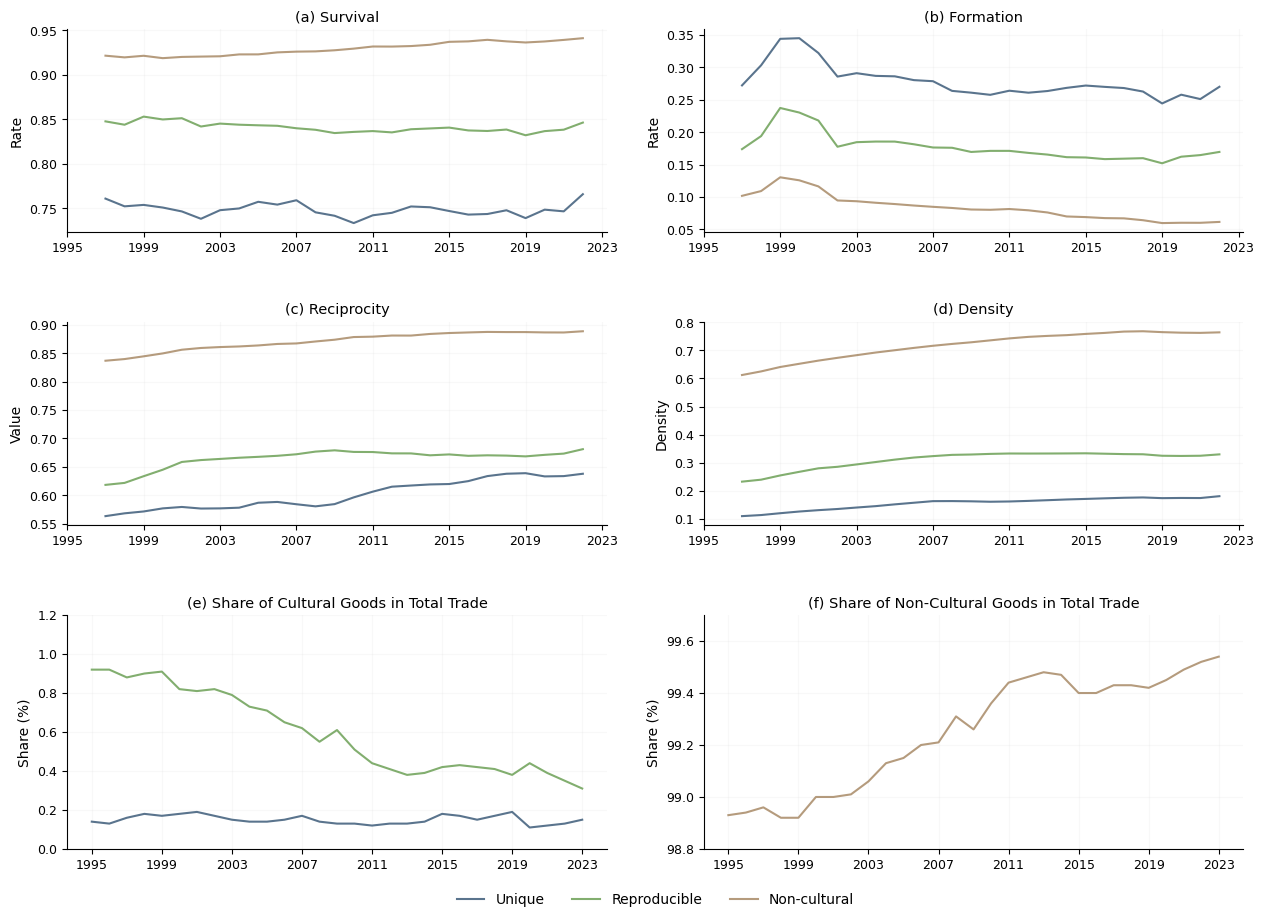

In [55]:
fig = plt.figure(figsize=(14, 10))
gs = gridspec.GridSpec(nrows=3, ncols=2, height_ratios=[1, 1, 1.15])
fig.subplots_adjust(left = 0.08, right = 0.92, top = 0.92, hspace = 0.42, wspace = 0.18, bottom = 0.10)

ax00 = fig.add_subplot(gs[0, 0])   # survival
ax01 = fig.add_subplot(gs[0, 1])   # formation
ax10 = fig.add_subplot(gs[1, 0])   # reciprocity
ax11 = fig.add_subplot(gs[1, 1])   # density
# Bottom row split into two panels
ax20 = fig.add_subplot(gs[2, 0])   # unique + reproducible share
ax21 = fig.add_subplot(gs[2, 1])   # non-cultural share

c_unique = "#486581"     
c_reprod = "#74a55f"    
c_non = "#9C7A52"        
lw = 1.5
alpha = 0.9
title_size = 10.5
label_size = 10
tick_size = 9

# COMMON FORMATTER
def style_axis(ax):
    ax.set_xticks(range(1995, 2024, 4))
    ax.tick_params(axis='x', labelsize=tick_size)
    ax.tick_params(axis='y', labelsize=tick_size)
    ax.grid(alpha=0.08)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# (a) Tie Survival Rate
ax00.plot(network_metrics["year"], network_metrics["survival_u_smooth"], color=c_unique, linewidth=lw, alpha=alpha)
ax00.plot(network_metrics["year"], network_metrics["survival_r_smooth"], color=c_reprod, linewidth=lw, alpha=alpha)
ax00.plot(network_metrics["year"], network_metrics["survival_t_smooth"], color=c_non, linewidth=lw, alpha = 0.75)
ax00.set_title("(a) Survival", fontsize=title_size, fontweight = 'normal')
ax00.set_ylabel("Rate", fontsize=label_size)
style_axis(ax00)

# (b) Tie Formation Rate
ax01.plot(network_metrics["year"],network_metrics["formation_u_smooth"],color=c_unique,linewidth=lw,alpha=alpha)
ax01.plot(network_metrics["year"],network_metrics["formation_r_smooth"],color=c_reprod,linewidth=lw,alpha=alpha)
ax01.plot(network_metrics["year"],network_metrics["formation_t_smooth"],color=c_non,linewidth=lw,alpha= 0.75)
ax01.set_title( "(b) Formation",fontsize=title_size,fontweight='normal')
ax01.set_ylabel("Rate", fontsize=label_size)
style_axis(ax01)

# (c) Reciprocity
ax10.plot(network_metrics["year"], network_metrics["reciprocity_u_smooth"], color=c_unique, linewidth=lw,alpha=alpha)
ax10.plot(network_metrics["year"], network_metrics["reciprocity_r_smooth"], color=c_reprod, linewidth=lw, alpha=alpha)
ax10.plot(network_metrics["year"], network_metrics["reciprocity_t_smooth"], color=c_non, linewidth=lw,alpha= 0.75)
ax10.set_title("(c) Reciprocity",fontsize=title_size,fontweight='normal')
ax10.set_ylabel("Value", fontsize=label_size)
style_axis(ax10)

# (d) Network Density
ax11.plot(network_metrics["year"],network_metrics["density_u_smooth"], color=c_unique,linewidth=lw, alpha=alpha)
ax11.plot(network_metrics["year"],network_metrics["density_r_smooth"], color=c_reprod, linewidth=lw, alpha=alpha)
ax11.plot(network_metrics["year"],network_metrics["density_t_smooth"], color=c_non, linewidth=lw, alpha= 0.75)
ax11.set_title( "(d) Density", fontsize=title_size,fontweight='normal')
ax11.set_ylabel("Density", fontsize=label_size)
style_axis(ax11)


# (e) Unique + Reproducible Trade Share
ax20.plot(panel_3["year"], panel_3["percentage_u"],color=c_unique,linewidth=lw,alpha=alpha)
ax20.plot(panel_3["year"],panel_3["percentage_r"],color=c_reprod,linewidth=lw,alpha=alpha)
ax20.set_title("(e) Share of Cultural Goods in Total Trade",fontsize=title_size,fontweight='normal')
ax20.set_ylabel("Share (%)", fontsize=label_size)
ax20.set_ylim(0, 1.2)
style_axis(ax20)

# (f) Non-cultural Trade Share
ax21.plot(panel_3["year"],panel_3["percentage_n"],color=c_non,linewidth=lw,alpha= 0.75)
ax21.set_title( "(f) Share of Non-Cultural Goods in Total Trade",fontsize=title_size,fontweight='normal')
ax21.set_ylabel("Share (%)", fontsize=label_size)
ax21.set_ylim(98.8, 99.7)
style_axis(ax21)

# Shared legend
fig.legend(['Unique', 'Reproducible', 'Non-cultural'],loc='lower center',ncol=3, fontsize=10, frameon=False, bbox_to_anchor=(0.5, 0.03))


plt.show()
fig.savefig('../results/Fig1.tiff', format="tiff")

In [34]:
---

SyntaxError: invalid syntax (1947214667.py, line 1)

In [ ]:
# Notes: The figure uses dual y-axes to improve visual comparability across trade categories with substantially different percentage shares.

Weighted directed centrality and clustering measures are computed using the wdnet package, while network density and reciprocity are calculated using igraph due to its broader implementation of global structural network statistics.

A. Survival rate
persistence,
durable trade ties,
STERGM dissolution process.
B. Formation rate
openness,
new tie creation,
network expansion dynamics.
C. Reciprocity
Because cultural exchange often implies:
mutual recognition,
reciprocal circulation.

This is theoretically meaningful.

Figure 3
Relational dynamics:
•	survival, 
•	dissolution, 
•	formation, 
•	reciprocity. 
________________________________________
Figure 4
Structural topology:
•	density, 
•	clustering. 


The figure compares the evolution of relational and structural characteristics across unique cultural goods, reproducible cultural goods, and non-cultural commodities between 2000 and 2023.
Then explain:
survival,reciprocity,density,etc.
This signals:
deliberate conceptual organization.

Trade relationships in non-reproducible cultural goods exhibit substantially lower survival rates and higher turnover compared to reproducible cultural goods and conventional commodities.

it visually suggests:

unique goods create more episodic/new ties,
while non-cultural networks stabilize.

This is conceptually important because:

it maps directly to STERGM dissolution.

Excellent coherence between:

descriptive analysis,
econometric framework.

Reviewers like this.

4. Reciprocity Panel
VERY strong figure.

Honestly,
this may be the most theoretically interesting subplot.

Because:

unique goods show lower reciprocity,
reproducible goods become more reciprocal over time,
non-cultural trade is highly reciprocal.

This strongly supports:

relational asymmetry in unique cultural exchange.

Very publishable insight.

IMPORTANT:
Reciprocity is much more theoretically interesting than density.

This matters.


## Distribution plot

In [38]:
attribute = att.copy()

In [39]:
attribute.columns

Index(['iso_o', 'iso_d', 'year', 'noncultural_trade',
       'hysteresis_noncultural_trade', 'unique', 'hysteresis_unique',
       'reproducible', 'hysteresis_reproducible', 'rta', 'country', 'gdp_pc',
       'trade_ratio', 'log_gdp_pc', 'D_log_gdp_pc', 'contig', 'comlang_off',
       'colony', 'comcol', 'dist', 'log_dist', 'landlocked', 'continent',
       'lat', 'lon', 'langoff_1', 'colonizer1', 'category', 'development',
       'country_d', 'gdp_pc_d', 'trade_ratio_d', 'log_gdp_pc_d',
       'D_log_gdp_pc_d', 'landlocked_d', 'continent_d', 'langoff_1_d',
       'colonizer1_d', 'category_d', 'development_d', 'dyad_id'],
      dtype='object')

In [40]:
attribute['absdiff_D_log_gdp_pc'] = np.abs(attribute['D_log_gdp_pc'] - attribute['D_log_gdp_pc_d'])
attribute['sum_D_log_gdp_pc'] = attribute['D_log_gdp_pc'] + attribute['D_log_gdp_pc_d']

In [41]:
# Constructing development mix dummies
attribute['mix_development_0_0'] = ((attribute['development'] == 0) & (attribute['development_d'] == 0)).astype(int)
attribute['mix_development_0_1'] = ((attribute['development'] == 0) & (attribute['development_d'] == 1)).astype(int)
attribute['mix_development_1_0'] = ((attribute['development'] == 1) & (attribute['development_d'] == 0)).astype(int)
attribute['mix_development_1_1'] = ((attribute['development'] == 1) & (attribute['development_d'] == 1)).astype(int)

In [42]:
# Creating landlockedness match dummy
attribute['nodematch_landlocked'] = ((attribute['landlocked'] == 1) & (attribute['landlocked_d'] == 1)).astype(int)

In [43]:
# Melting the trade types into a single categorical column named 'Product_Type', while retaining all the contextual
# continuous and binary metrics as identifier variables
id_vars = ['dyad_id', 'year', 'log_dist', 'log_gdp_pc', 'D_log_gdp_pc', 'absdiff_D_log_gdp_pc','sum_D_log_gdp_pc', 'rta','contig', 'comlang_off',
'colony', 'comcol', 'nodematch_landlocked','mix_development_0_0', 'mix_development_0_1', 'mix_development_1_0', 'mix_development_1_1']
attribute_long = pd.melt(attribute, id_vars = id_vars, value_vars = ['unique', 'reproducible', 'noncultural_trade'], var_name='Product_Type', value_name='Trade_Value')


In [44]:
# Changing column labels
attribute_long['Product_Type'] = attribute_long['Product_Type'].replace({'unique': 'Unique Cultural Goods',
'reproducible': 'Reproducible Cultural Goods', 'noncultural_trade': 'Non-cultural Goods'})

In [45]:
attribute_long[(attribute_long['dyad_id'] =='ABW-AFG') & (attribute_long['year'] == 2000)].head()

,dyad_id,year,log_dist,log_gdp_pc,D_log_gdp_pc,absdiff_D_log_gdp_pc,sum_D_log_gdp_pc,rta,contig,comlang_off,colony,comcol,nodematch_landlocked,mix_development_0_0,mix_development_0_1,mix_development_1_0,mix_development_1_1,Product_Type,Trade_Value
5,ABW-AFG,2000,9.492342,10.532737,0.063155,2.425694,-2.299384,0.0,0,0,0,0,0,1,0,0,0,Unique Cultural Goods,0.0
1041395,ABW-AFG,2000,9.492342,10.532737,0.063155,2.425694,-2.299384,0.0,0,0,0,0,0,1,0,0,0,Reproducible Cultural Goods,0.0
2082785,ABW-AFG,2000,9.492342,10.532737,0.063155,2.425694,-2.299384,0.0,0,0,0,0,0,1,0,0,0,Non-cultural Goods,0.0


In [46]:
attribute_long.columns

Index(['dyad_id', 'year', 'log_dist', 'log_gdp_pc', 'D_log_gdp_pc',
       'absdiff_D_log_gdp_pc', 'sum_D_log_gdp_pc', 'rta', 'contig',
       'comlang_off', 'colony', 'comcol', 'nodematch_landlocked',
       'mix_development_0_0', 'mix_development_0_1', 'mix_development_1_0',
       'mix_development_1_1', 'Product_Type', 'Trade_Value'],
      dtype='object')

In [47]:
# Time-Invariant: Filter to unique dyads to prevent duplication of fixed terms
attribute_fixed = attribute_long.drop_duplicates(subset=['dyad_id', 'Product_Type'])

In [48]:
df_rta_unique = attribute_long.drop_duplicates(subset=['year', 'dyad_id'])
rta_trends = df_rta_unique.groupby('year')['rta'].sum().reset_index()

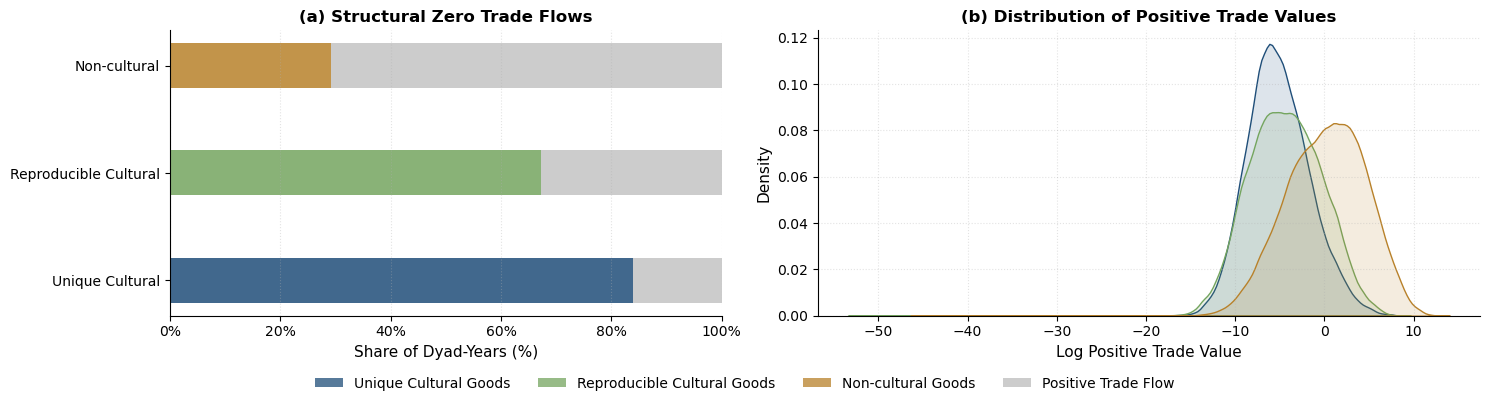

In [60]:
palette = {'Unique Cultural Goods': "#1F4E79", 'Reproducible Cultural Goods': "#74a55f", 'Non-cultural Goods': "#B8812A" }
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(15, 4),gridspec_kw={'width_ratios': [1, 1.2]})
plt.subplots_adjust(wspace=0.06)

# PANEL (a): STRUCTURAL ZERO FLOWS
zero_rates = {'Unique Cultural Goods': (attribute['unique'] == 0).mean() * 100,
    'Reproducible Cultural Goods': (attribute['reproducible'] == 0).mean() * 100,
    'Non-cultural Goods': (attribute['noncultural_trade'] == 0).mean() * 100}
categories = list(zero_rates.keys())
zero_shares = list(zero_rates.values())
positive_shares = [100 - x for x in zero_shares]
labels = ["Unique Cultural","Reproducible Cultural","Non-cultural"]
# bars
for i, cat in enumerate(categories):
    # zero-flow share
    ax1.barh(labels[i], zero_shares[i], color=palette[cat],alpha=0.85,height=0.42)
    # positive-flow share
    ax1.barh(labels[i],positive_shares[i],left=zero_shares[i],color = "#cccccc", height = 0.42)
# formatting
ax1.set_xlim(0, 100)
ax1.set_xlabel("Share of Dyad-Years (%)", fontsize=11)
ax1.set_title("(a) Structural Zero Trade Flows",fontsize=12,fontweight='bold')
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}%'))
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(axis='x',linestyle=':',alpha=0.35)
ax1.tick_params(axis='both', labelsize=10)
# positive trade only
df_positive = attribute_long[attribute_long['Trade_Value'] > 0].copy()
# log transformation
df_positive['log_trade_val'] = np.log(df_positive['Trade_Value'])

# Panel b: KDE plots
for category in categories:
    subset = df_positive[df_positive['Product_Type'] == category]
    sns.kdeplot(data=subset, x='log_trade_val',fill = True, alpha= 0.15, linewidth = 1,color=palette[category],ax=ax2,label=category)
# formatting
ax2.set_title("(b) Distribution of Positive Trade Values",fontsize=12,fontweight='bold')
ax2.set_xlabel( "Log Positive Trade Value",fontsize=11)
ax2.set_ylabel("Density", fontsize=11)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(linestyle=':',alpha=0.35)
ax2.tick_params(axis='both', labelsize=10)
legend_elements = [
    Patch(facecolor=palette['Unique Cultural Goods'],alpha=0.75,label='Unique Cultural Goods'),
    Patch(facecolor=palette['Reproducible Cultural Goods'],alpha=0.75,label='Reproducible Cultural Goods'),
    Patch(facecolor=palette['Non-cultural Goods'],alpha=0.75,label='Non-cultural Goods'),
    Patch(facecolor='#cccccc',label='Positive Trade Flow')]
fig.legend(handles=legend_elements,loc='lower center',ncol=4,frameon=False,fontsize=10,bbox_to_anchor=(0.5, -0.02))
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

fig.savefig('../results/Fig5.tiff', format="tiff")